# Sistema de clasificación para predecir el abandono de clientes

**Proyecto aplicado de Ciencia de Datos — UIDE**  
**Estudiante:** Karen Núñez Loor  
**Tema:** Predicción del abandono de clientes de telecomunicaciones  
**Tipo de problema:** Clasificación binaria

---

## Estructura del proyecto

El notebook presenta el desarrollo completo de una solución de Ciencia de Datos para analizar y predecir el abandono de clientes. Se incluyen las etapas de adquisición, auditoría y preparación de datos, análisis exploratorio, consultas SQL, visualización, modelado predictivo, evaluación, interpretación y análisis ético.

## 1. Planteamiento del problema

El abandono de clientes, conocido como *customer churn*, representa un desafío para las empresas de telecomunicaciones, debido a que la pérdida de clientes puede afectar sus ingresos y generar la necesidad de destinar recursos a la captación de nuevos usuarios. La identificación anticipada de patrones asociados al abandono puede servir como apoyo para orientar acciones de atención, soporte y retención.

**Pregunta principal:** ¿qué clientes presentan mayor probabilidad de abandono y qué variables están asociadas con este resultado?

**Unidad de análisis:** cada fila del conjunto de datos representa un cliente.  
**Variable objetivo:** `Churn`, con valores `Yes` (abandono) y `No` (permanencia).  
**Uso previsto:** estimar el riesgo de abandono como herramienta de apoyo para la revisión de casos y la orientación de estrategias de retención.  
**Uso no previsto:** utilizar las predicciones para negar servicios, incrementar precios de forma individualizada o tomar decisiones automáticas que puedan perjudicar a los clientes.

### Objetivos específicos

1. Examinar la calidad de los datos y realizar su limpieza y preparación.
2. Realizar consultas mediante SQL y aplicar análisis estadístico sobre las principales variables.
3. Explorar y visualizar los patrones relacionados con el abandono de clientes.
4. Construir y comparar una línea base, un modelo de Regresión Logística y un modelo Random Forest.
5. Evaluar los modelos mediante métricas adecuadas para un problema de clasificación con clases desbalanceadas.
6. Interpretar los resultados del modelo y analizar aspectos relacionados con ética, privacidad y uso responsable de los datos.

## 2. Preparación del entorno

Se importa las librerías necesarias para desarrollar el proyecto. `pandas` y `numpy` se utilizan para la manipulación y análisis de datos; `matplotlib` y `seaborn` para la visualización; `sqlite3` para realizar consultas SQL; `scipy` para el análisis estadístico; y `scikit-learn` para el preprocesamiento, entrenamiento y evaluación de los modelos de clasificación.

También se utiliza `joblib` para guardar el modelo entrenado al finalizar el proyecto.

La constante `RANDOM_STATE = 42` permite controlar los procesos aleatorios utilizados durante el análisis, facilitando la reproducibilidad de la partición de los datos y del entrenamiento de los modelos.

In [1]:
from pathlib import Path
import sqlite3
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="colorblind")

RANDOM_STATE = 42
print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 3. Adquisición de datos

Para el desarrollo del proyecto se utiliza el dataset público **IBM Telco Customer Churn**, que contiene información relacionada con características demográficas generales, servicios contratados, permanencia, facturación y abandono de clientes.

- **Fuente:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d)
- **Archivo:** `Telco-Customer-Churn.csv`

El conjunto de datos contiene **7.043 registros y 21 variables originales**. El código busca primero el archivo local y, si no está disponible, intenta cargarlo desde la fuente pública documentada.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
)

local_candidates = [
    Path("/content/Telco-Customer-Churn.csv"),
]

data_source = next(
    (path for path in local_candidates if path.exists()),
    DATA_URL
)

df_raw = pd.read_csv(data_source)

print(f"Fuente utilizada: {data_source}")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
display(df_raw.head())

Fuente utilizada: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Filas: 7,043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Diccionario de datos

Con el propósito de comprender la estructura del conjunto de datos antes de realizar el análisis, se construye un diccionario que identifica cada variable, su tipo de dato original y una breve descripción de su contenido.

Esta documentación permite interpretar correctamente las variables y facilita las etapas posteriores de limpieza, análisis exploratorio y modelado.

In [3]:
descripciones = {
    "customerID": "Identificador único del cliente",
    "gender": "Género registrado",
    "SeniorCitizen": "Indica si es adulto mayor (1 sí, 0 no)",
    "Partner": "Indica si tiene pareja",
    "Dependents": "Indica si tiene dependientes",
    "tenure": "Meses de permanencia en la empresa",
    "PhoneService": "Tiene servicio telefónico",
    "MultipleLines": "Tiene varias líneas telefónicas",
    "InternetService": "Tipo de servicio de internet",
    "OnlineSecurity": "Tiene seguridad en línea",
    "OnlineBackup": "Tiene respaldo en línea",
    "DeviceProtection": "Tiene protección de dispositivo",
    "TechSupport": "Tiene soporte técnico",
    "StreamingTV": "Tiene televisión por streaming",
    "StreamingMovies": "Tiene películas por streaming",
    "Contract": "Tipo de contrato",
    "PaperlessBilling": "Usa facturación sin papel",
    "PaymentMethod": "Método de pago",
    "MonthlyCharges": "Cargo mensual",
    "TotalCharges": "Cargos acumulados",
    "Churn": "Abandonó durante el último mes (variable objetivo)",
}

diccionario = pd.DataFrame(
    {
        "variable": df_raw.columns,
        "tipo_original": df_raw.dtypes.astype(str).values,
        "descripcion": [descripciones[col] for col in df_raw.columns],
    }
)
display(diccionario)

,variable,tipo_original,descripcion
0,customerID,object,Identificador único del cliente
1,gender,object,Género registrado
2,SeniorCitizen,int64,"Indica si es adulto mayor (1 sí, 0 no)"
3,Partner,object,Indica si tiene pareja
4,Dependents,object,Indica si tiene dependientes
5,tenure,int64,Meses de permanencia en la empresa
6,PhoneService,object,Tiene servicio telefónico
7,MultipleLines,object,Tiene varias líneas telefónicas
8,InternetService,object,Tipo de servicio de internet
9,OnlineSecurity,object,Tiene seguridad en línea


## 5. Auditoría de calidad

Antes de realizar el análisis exploratorio y entrenar los modelos, se revisa la calidad inicial del conjunto de datos. Para ello se verifican dimensiones, tipos de datos, valores faltantes, espacios vacíos, registros duplicados y unicidad del identificador de cliente.

Esta etapa permite detectar inconsistencias que podrían afectar el análisis y el desempeño posterior de los modelos.

In [4]:
auditoria = pd.Series(
    {
        "filas": len(df_raw),
        "columnas": df_raw.shape[1],
        "duplicados_exactos": df_raw.duplicated().sum(),
        "identificadores_duplicados": df_raw["customerID"].duplicated().sum(),
        "nulos_reconocidos": df_raw.isna().sum().sum(),
        "espacios_vacios_TotalCharges": (
            df_raw["TotalCharges"]
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        ),
    },
    name="resultado",
)

display(auditoria.to_frame())

,resultado
filas,7043
columnas,21
duplicados_exactos,0
identificadores_duplicados,0
nulos_reconocidos,0
espacios_vacios_TotalCharges,11


### Interpretación de la auditoría

El conjunto de datos contiene **7.043 registros y 21 variables originales**. No se identificaron filas completamente duplicadas ni identificadores de cliente repetidos.

Aunque `pandas` no reconoce inicialmente valores nulos, se detectaron **11 registros con espacios vacíos en la variable `TotalCharges`**. Esta situación explica por qué la variable fue cargada originalmente como tipo `object`, a pesar de representar valores monetarios.

Por lo tanto, será necesario convertir `TotalCharges` a formato numérico y revisar estos 11 registros durante la etapa de limpieza.

In [5]:
mask_total_vacio = df_raw["TotalCharges"].astype(str).str.strip().eq("")
display(df_raw.loc[mask_total_vacio, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Revisión de los valores vacíos en `TotalCharges`

Se identificaron 11 registros con valores vacíos en la variable `TotalCharges`. Al revisar estos casos se observó que todos corresponden a clientes con `tenure = 0`, es decir, clientes que no registran meses acumulados de permanencia.

Por esta razón, en la etapa de limpieza estos valores se tratarán como 0, manteniendo los registros dentro del conjunto de datos.

## 6. Limpieza

Se crea una copia del conjunto de datos original para conservar intacta la información cargada inicialmente.

Durante esta etapa se realizan las siguientes transformaciones:

1. Se convierte `TotalCharges` a formato numérico. Los espacios vacíos se transforman inicialmente en valores `NaN`.
2. Dado que los 11 registros con `TotalCharges` vacío corresponden a clientes con `tenure = 0`, se asigna un valor de 0 a `TotalCharges` en esos casos.
3. Se convierte `SeniorCitizen` a etiquetas más legibles (`No` y `Yes`).
4. Se crea la variable `ChurnFlag`, donde `No = 0` y `Yes = 1`, para utilizarla como variable objetivo durante el modelado.

La variable `customerID` se conserva para trazabilidad, pero posteriormente se excluirá del modelo porque funciona únicamente como identificador y no como característica predictiva del cliente.

In [6]:
# Crear una copia del dataset original
df = df_raw.copy()

# Convertir TotalCharges a formato numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Reemplazar TotalCharges por 0 únicamente
# cuando el cliente tiene tenure igual a 0
df.loc[
    (df["TotalCharges"].isnull()) &
    (df["tenure"] == 0),
    "TotalCharges"
] = 0

# Convertir SeniorCitizen a etiquetas más comprensibles
df["SeniorCitizen"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

# Crear variable objetivo numérica
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Verificación final
print("Valores nulos en TotalCharges:", df["TotalCharges"].isnull().sum())
print("Tipo de TotalCharges:", df["TotalCharges"].dtype)
print("Dimensiones del dataset:", df.shape)

display(
    df[["SeniorCitizen", "Churn", "ChurnFlag"]].head()
)

Valores nulos en TotalCharges: 0
Tipo de TotalCharges: float64
Dimensiones del dataset: (7043, 22)


,SeniorCitizen,Churn,ChurnFlag
0,No,No,0
1,No,No,0
2,No,Yes,1
3,No,No,0
4,No,Yes,1


In [7]:
resumen_limpieza = pd.DataFrame(
    {
        "tipo_limpio": df.dtypes.astype(str),
        "faltantes": df.isna().sum(),
        "valores_unicos": df.nunique(dropna=False),
    }
)

display(resumen_limpieza)

,tipo_limpio,faltantes,valores_unicos
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,object,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


## 7. Gestión y consulta con SQL

Se utiliza SQL mediante SQLite, un motor de base de datos relacional incluido en Python que no requiere la instalación de un servidor externo.

El DataFrame limpio se almacena temporalmente en una tabla denominada `clientes`. A partir de esta tabla se realizan consultas para obtener indicadores generales y analizar el abandono según el tipo de contrato.

En las consultas se utilizan funciones de agregación como `COUNT()` y `AVG()`, además de `GROUP BY` para comparar grupos de clientes.

In [8]:
conexion = sqlite3.connect(":memory:")

df.to_sql(
    "clientes",
    conexion,
    index=False,
    if_exists="replace"
)

print("Tabla 'clientes' creada correctamente en SQLite.")

Tabla 'clientes' creada correctamente en SQLite.


In [9]:
consulta_general = """
SELECT
    COUNT(*) AS clientes,
    ROUND(100.0 * AVG(ChurnFlag), 2) AS tasa_abandono_pct,
    ROUND(AVG(MonthlyCharges), 2) AS cargo_mensual_promedio,
    ROUND(AVG(TotalCharges), 2) AS cargo_total_promedio
FROM clientes;
"""

resultado_general = pd.read_sql_query(
    consulta_general,
    conexion
)

display(resultado_general)

,clientes,tasa_abandono_pct,cargo_mensual_promedio,cargo_total_promedio
0,7043,26.54,64.76,2279.73


### Interpretación

La consulta resume el conjunto de datos mediante indicadores generales como el número total de clientes, la tasa de abandono y los cargos promedio.

La tasa de abandono se calcula utilizando el promedio de `ChurnFlag`, debido a que esta variable toma el valor 1 cuando el cliente abandona y 0 cuando permanece.

In [10]:
consulta_contrato = """
SELECT
    Contract AS contrato,
    COUNT(*) AS clientes,
    SUM(ChurnFlag) AS abandonos,
    ROUND(100.0 * AVG(ChurnFlag), 2) AS tasa_abandono_pct,
    ROUND(AVG(tenure), 1) AS permanencia_promedio_meses
FROM clientes
GROUP BY Contract
ORDER BY tasa_abandono_pct DESC;
"""

resultado_contrato = pd.read_sql_query(
    consulta_contrato,
    conexion
)

display(resultado_contrato)

,contrato,clientes,abandonos,tasa_abandono_pct,permanencia_promedio_meses
0,Month-to-month,3875,1655,42.71,18.0
1,One year,1473,166,11.27,42.0
2,Two year,1695,48,2.83,56.7


### Interpretación de la consulta por contrato

La consulta permite comparar el comportamiento de los clientes según el tipo de contrato. Las diferencias observadas en la tasa de abandono muestran una asociación entre ambas variables.

Sin embargo, estas diferencias no permiten afirmar que el tipo de contrato sea la causa directa del abandono, ya que también pueden intervenir otros factores como la permanencia, los cargos o los servicios contratados.

## 8. Análisis exploratorio de datos

El análisis exploratorio de datos, conocido como EDA (*Exploratory Data Analysis*), permite identificar patrones, distribuciones y relaciones relevantes antes de construir los modelos predictivos.

En esta etapa se analiza la distribución de la variable objetivo, el comportamiento del abandono según distintas características categóricas y las diferencias observadas en variables numéricas.

Los resultados obtenidos permiten identificar asociaciones entre variables, pero no demuestran relaciones causales.

,clientes,porcentaje
abandono,,
No,5174,73.46
Yes,1869,26.54


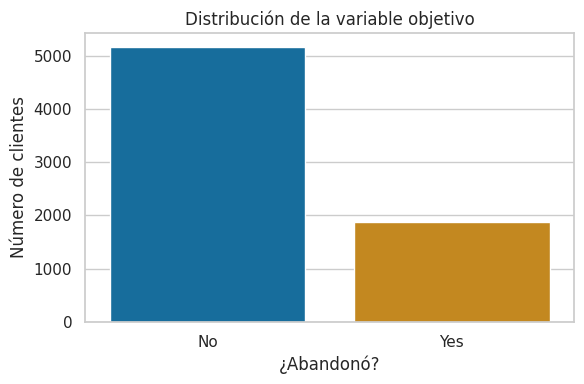

In [11]:
distribucion = (
    df["Churn"]
    .value_counts()
    .rename_axis("abandono")
    .to_frame("clientes")
)

distribucion["porcentaje"] = (
    100 * distribucion["clientes"] / len(df)
).round(2)

display(distribucion)

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False,
    ax=ax
)

ax.set(
    title="Distribución de la variable objetivo",
    xlabel="¿Abandonó?",
    ylabel="Número de clientes"
)

plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

De los 7.043 clientes analizados, 5.174 permanecieron en el servicio y 1.869 abandonaron. Esto representa una tasa de abandono del **26,54 %**.

La distribución evidencia un desbalance moderado entre las clases, debido a que aproximadamente tres de cada cuatro clientes pertenecen a la categoría `No`. Por esta razón, durante la evaluación de los modelos no se utilizará únicamente `accuracy`, sino también métricas como `precision`, `recall`, `F1`, `ROC-AUC` y `PR-AUC`.

In [12]:
def tabla_tasa(columna):
    """Resume cantidad y tasa de abandono para una variable categórica."""

    return (
        df.groupby(columna, dropna=False)
        .agg(
            clientes=("ChurnFlag", "size"),
            abandonos=("ChurnFlag", "sum"),
            tasa_abandono=("ChurnFlag", "mean")
        )
        .assign(
            tasa_abandono_pct=lambda x:
            (100 * x["tasa_abandono"]).round(2)
        )
        .drop(columns="tasa_abandono")
        .sort_values(
            "tasa_abandono_pct",
            ascending=False
        )
    )

In [13]:
for variable in [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport"
]:
    print(f"\nAbandono por {variable}")
    display(tabla_tasa(variable))


Abandono por Contract


,clientes,abandonos,tasa_abandono_pct
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83



Abandono por InternetService


,clientes,abandonos,tasa_abandono_pct
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40



Abandono por PaymentMethod


,clientes,abandonos,tasa_abandono_pct
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24



Abandono por TechSupport


,clientes,abandonos,tasa_abandono_pct
TechSupport,,,
No,3473,1446,41.64
Yes,2044,310,15.17
No internet service,1526,113,7.40


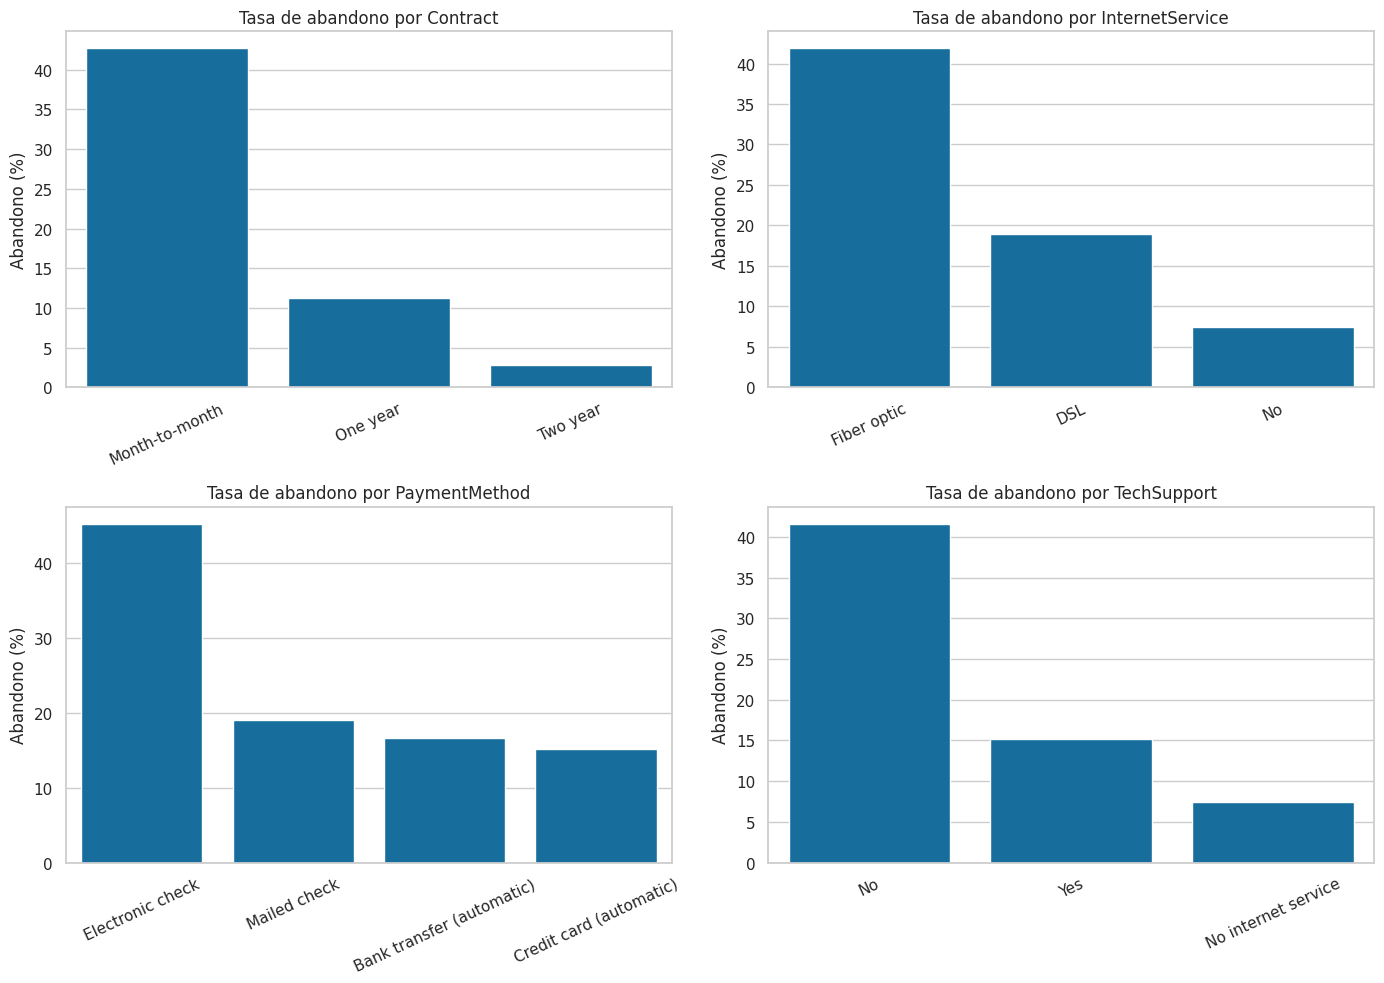

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport"
]

for ax, variable in zip(axes.flat, variables):
    tasas = tabla_tasa(variable).reset_index()

    sns.barplot(
        data=tasas,
        x=variable,
        y="tasa_abandono_pct",
        ax=ax
    )

    ax.set(
        title=f"Tasa de abandono por {variable}",
        xlabel="",
        ylabel="Abandono (%)"
    )

    ax.tick_params(
        axis="x",
        rotation=25
    )

plt.tight_layout()
plt.show()

### Interpretación de variables categóricas

Las tasas de abandono presentan diferencias entre las distintas categorías analizadas.

El tipo de contrato muestra una de las relaciones más claras: los clientes con contratos mes a mes presentan una proporción de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

También se observan diferencias asociadas con el tipo de servicio de internet, el método de pago y la disponibilidad de soporte técnico.

Estas diferencias representan asociaciones observadas en los datos y no implican necesariamente una relación causal.

## 9. Análisis estadístico

Como complemento del análisis exploratorio, se aplican dos pruebas estadísticas para evaluar las diferencias y asociaciones observadas en los datos:

- **Prueba de Chi-cuadrado:** permite evaluar si existe una asociación estadísticamente significativa entre dos variables categóricas. En este caso se analiza la relación entre `Contract` y `Churn`.
- **Prueba U de Mann–Whitney:** permite comparar la distribución de una variable numérica entre dos grupos sin asumir que los datos siguen una distribución normal. En este caso se compara `tenure` entre clientes que abandonaron y clientes que permanecieron.

Se utiliza un nivel de significancia de **α = 0,05**. Un valor `p < 0,05` proporciona evidencia para rechazar la hipótesis nula correspondiente. Sin embargo, la significancia estadística no implica causalidad ni necesariamente una diferencia de importancia práctica.

In [15]:
# Chi-cuadrado: Contract vs Churn
tabla_contingencia = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi2, p_chi, grados_libertad, _ = chi2_contingency(
    tabla_contingencia
)

# V de Cramér como medida de asociación
n = tabla_contingencia.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 /
    (
        n * min(
            tabla_contingencia.shape[0] - 1,
            tabla_contingencia.shape[1] - 1
        )
    )
)

# Mann-Whitney U: tenure según Churn
grupo_no = df.loc[
    df["Churn"] == "No",
    "tenure"
]

grupo_si = df.loc[
    df["Churn"] == "Yes",
    "tenure"
]

u_stat, p_u = mannwhitneyu(
    grupo_no,
    grupo_si,
    alternative="two-sided"
)

# Resumen de resultados
resultados_estadisticos = pd.DataFrame(
    {
        "prueba": [
            "Chi-cuadrado: Contract vs Churn",
            "Mann-Whitney: tenure por Churn"
        ],
        "estadistico": [
            chi2,
            u_stat
        ],
        "p_valor": [
            p_chi,
            p_u
        ],
        "medida_adicional": [
            f"V de Cramér = {cramers_v:.3f}",
            "Comparación no paramétrica"
        ],
    }
)

display(resultados_estadisticos)

,prueba,estadistico,p_valor,medida_adicional
0,Chi-cuadrado: Contract vs Churn,1.184597e+03,5.863038e-258,V de Cramér = 0.410
1,Mann-Whitney: tenure por Churn,7.154668e+06,2.419636e-208,Comparación no paramétrica


### Interpretación de las pruebas estadísticas

La prueba de Chi-cuadrado aplicada entre `Contract` y `Churn` obtuvo un valor p de aproximadamente **5,86 × 10⁻²⁵⁸**, claramente inferior al nivel de significancia de 0,05. Por lo tanto, se rechaza la hipótesis nula de independencia y se concluye que existe evidencia estadística de una asociación entre el tipo de contrato y el abandono de clientes.

La **V de Cramér = 0,410** indica que la asociación observada tiene una magnitud relevante dentro del conjunto de datos, complementando el resultado obtenido mediante Chi-cuadrado.

Por otra parte, la prueba U de Mann–Whitney utilizada para comparar `tenure` entre los clientes que permanecieron y aquellos que abandonaron obtuvo un valor p de aproximadamente **2,42 × 10⁻²⁰⁸**, también inferior a 0,05. Esto proporciona evidencia estadística de que la distribución del tiempo de permanencia difiere entre ambos grupos.

## 10. Preparación para aprendizaje automático

Se separan las variables predictoras (`X`) de la variable objetivo (`y`).

Se excluyen:

- `customerID`, porque corresponde únicamente a un identificador;
- `Churn`, porque representa la variable objetivo en formato de texto;
- `ChurnFlag`, porque corresponde a la misma variable objetivo en formato numérico y mantenerla dentro de `X` produciría fuga de información (*data leakage*).

Posteriormente, el conjunto de datos se divide en dos partes:

- **80 % para entrenamiento**, utilizado para ajustar los modelos;
- **20 % para prueba**, reservado para la evaluación final.

El parámetro `stratify=y` permite conservar aproximadamente la misma proporción de abandono en ambos subconjuntos.

In [16]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "ChurnFlag"
    ]
)

y = df["ChurnFlag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba: {X_test.shape[0]:,} filas")
print(f"Abandono en entrenamiento: {y_train.mean():.2%}")
print(f"Abandono en prueba: {y_test.mean():.2%}")

Entrenamiento: 5,634 filas
Prueba: 1,409 filas
Abandono en entrenamiento: 26.54%
Abandono en prueba: 26.54%


### Transformaciones dentro de un pipeline

Para preparar los datos antes del entrenamiento se utiliza un `Pipeline`, que permite encadenar las transformaciones y el modelo dentro de un mismo flujo de trabajo.

Las variables numéricas se someten a imputación por mediana y estandarización. Las variables categóricas se imputan con la categoría más frecuente y posteriormente se transforman mediante codificación *one-hot*.

El uso del pipeline permite que las transformaciones aprendan sus parámetros únicamente a partir de los datos de entrenamiento, reduciendo el riesgo de fuga de información.

In [17]:
columnas_numericas = X.select_dtypes(include="number").columns.tolist()
columnas_categoricas = X.select_dtypes(exclude="number").columns.tolist()

pipeline_numerico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("escala", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, columnas_numericas),
        ("categoricas", pipeline_categorico, columnas_categoricas),
    ]
)

print("Numéricas:", columnas_numericas)
print("Categóricas:", columnas_categoricas)

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 11. Modelos candidatos

Se comparan tres enfoques de clasificación:

1. **Línea base:** utiliza siempre la clase más frecuente. Sirve como referencia mínima para verificar si los modelos de aprendizaje automático realmente aportan capacidad predictiva.
2. **Regresión Logística:** modelo de clasificación probabilístico e interpretable, ya que permite analizar la dirección y magnitud de sus coeficientes.
3. **Random Forest:** modelo basado en múltiples árboles de decisión que puede capturar relaciones no lineales y combinaciones más complejas entre las variables.

En la Regresión Logística y Random Forest se utiliza `class_weight="balanced"` para asignar mayor peso relativo a la clase minoritaria. Esto puede mejorar la detección de clientes que abandonan, aunque también puede incrementar la cantidad de falsos positivos.

In [18]:
modelos = {
    "Línea base": DummyClassifier(
        strategy="most_frequent"
    ),

    "Regresión Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

pipelines = {
    nombre: Pipeline(
        [
            ("preprocesamiento", preprocesador),
            ("modelo", modelo),
        ]
    )
    for nombre, modelo in modelos.items()
}

print("Modelos y pipelines preparados correctamente.")

Modelos y pipelines preparados correctamente.


## 12. Validación cruzada en el conjunto de entrenamiento

Para comparar los modelos de manera más robusta se utiliza validación cruzada estratificada de cinco particiones.

El conjunto de entrenamiento se divide en cinco partes. En cada iteración, el modelo se entrena con cuatro partes y se valida con la parte restante. Este procedimiento se repite hasta que cada partición haya sido utilizada como conjunto de validación.

Se utiliza `StratifiedKFold` para conservar aproximadamente la misma proporción de abandono en cada partición.

Las métricas utilizadas son:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los clientes clasificados como posibles abandonos, cuántos realmente abandonaron.
- **Recall:** de los clientes que realmente abandonaron, cuántos fueron detectados por el modelo.
- **F1:** media armónica entre precision y recall.
- **ROC-AUC:** capacidad general del modelo para discriminar entre clientes que abandonan y clientes que permanecen.
- **PR-AUC:** resume la relación entre precision y recall y resulta especialmente útil cuando la clase positiva es minoritaria.

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

metricas_cv = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

filas_cv = []

for nombre, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metricas_cv,
        n_jobs=-1,
    )

    fila = {"modelo": nombre}

    for metrica in metricas_cv:
        fila[f"{metrica}_media"] = scores[f"test_{metrica}"].mean()
        fila[f"{metrica}_desv"] = scores[f"test_{metrica}"].std()

    filas_cv.append(fila)

resultados_cv = (
    pd.DataFrame(filas_cv)
    .set_index("modelo")
    .round(3)
)

display(resultados_cv)

,accuracy_media,accuracy_desv,precision_media,precision_desv,recall_media,recall_desv,f1_media,f1_desv,roc_auc_media,roc_auc_desv,pr_auc_media,pr_auc_desv
modelo,,,,,,,,,,,,
Línea base,0.735,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000,0.265,0.000
Regresión Logística,0.748,0.015,0.517,0.019,0.801,0.038,0.628,0.023,0.846,0.012,0.660,0.020
Random Forest,0.782,0.011,0.575,0.018,0.686,0.035,0.625,0.022,0.841,0.009,0.646,0.024


### Interpretación de la validación cruzada

La línea base obtuvo un `accuracy` promedio de 0,735, pero un `recall` de 0, lo que confirma que predecir siempre la clase mayoritaria no permite identificar a los clientes que abandonan.

La Regresión Logística obtuvo un `accuracy` promedio de 0,748 y destacó por su `recall` de 0,801, lo que indica una mayor capacidad para detectar clientes que realmente abandonan. Además, alcanzó un `ROC-AUC` de 0,846 y un `PR-AUC` de 0,660.

Random Forest obtuvo el mayor `accuracy` promedio, con 0,782, y una mayor `precision` de 0,575. Sin embargo, su `recall` fue menor, con 0,686.

Dado que el objetivo del proyecto es identificar clientes con posible riesgo de abandono para apoyar acciones de retención, el recall tiene especial relevancia. Por esta razón, la Regresión Logística presenta un comportamiento especialmente útil para el objetivo planteado.

## 13. Evaluación final en el conjunto de prueba

Después de comparar los modelos mediante validación cruzada, cada pipeline se entrena utilizando todo el conjunto de entrenamiento y se evalúa una sola vez sobre el conjunto de prueba reservado.

Para la clasificación se mantiene el umbral estándar de **0,5**. Esto significa que, si la probabilidad estimada de abandono es igual o superior a 0,5, el cliente se clasifica como posible abandono.

Las métricas utilizadas son `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC` y `PR-AUC`.

La matriz de confusión permite distinguir cuatro tipos de resultados:

- **Verdaderos negativos:** clientes que permanecieron y fueron clasificados correctamente como permanencia.
- **Falsos positivos:** clientes que permanecieron, pero fueron clasificados como posible abandono.
- **Falsos negativos:** clientes que abandonaron, pero el modelo no logró detectarlos.
- **Verdaderos positivos:** clientes que abandonaron y fueron detectados correctamente.

In [20]:
def evaluar_modelo(nombre, pipeline, X_eval, y_eval):
    pred = pipeline.predict(X_eval)
    prob = pipeline.predict_proba(X_eval)[:, 1]

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, prob),
        "pr_auc": average_precision_score(y_eval, prob),
    }, pred, prob


resultados_test = []
predicciones = {}
probabilidades = {}

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    fila, pred, prob = evaluar_modelo(
        nombre,
        pipeline,
        X_test,
        y_test
    )

    resultados_test.append(fila)
    predicciones[nombre] = pred
    probabilidades[nombre] = prob


tabla_test = (
    pd.DataFrame(resultados_test)
    .set_index("modelo")
    .round(3)
)

display(tabla_test)

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Línea base,0.735,0.000,0.000,0.000,0.500,0.265
Regresión Logística,0.738,0.504,0.783,0.614,0.842,0.633
Random Forest,0.774,0.560,0.682,0.615,0.839,0.645


### Interpretación de la evaluación final

La línea base alcanzó un `accuracy` de 0,735, pero obtuvo `recall = 0`, lo que significa que no identificó correctamente ningún caso de abandono. Este resultado demuestra por qué el `accuracy` no debe utilizarse de forma aislada en este problema.

Random Forest obtuvo el mayor `accuracy` (0,774) y la mayor `precision` (0,560). Sin embargo, la Regresión Logística alcanzó un `recall` de 0,783, superior al 0,682 obtenido por Random Forest.

La Regresión Logística también presentó un `ROC-AUC` ligeramente superior, con 0,842 frente a 0,839 de Random Forest.

Dado que el objetivo del proyecto es detectar clientes con posible riesgo de abandono para apoyar acciones de retención, se considera especialmente importante identificar la mayor proporción posible de abandonos reales. Por esta razón, la Regresión Logística se selecciona como modelo principal.

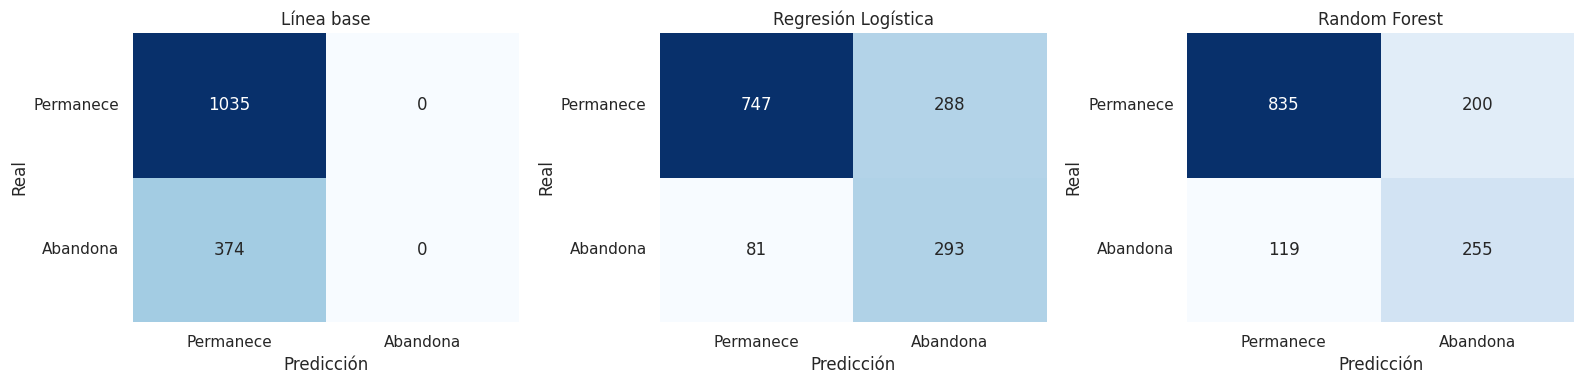

In [21]:
fig, axes = plt.subplots(
    1,
    len(pipelines),
    figsize=(16, 4)
)

for ax, (nombre, pred) in zip(
    axes,
    predicciones.items()
):
    matriz = confusion_matrix(
        y_test,
        pred
    )

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set(
        title=nombre,
        xlabel="Predicción",
        ylabel="Real"
    )

    ax.set_xticklabels(
        ["Permanece", "Abandona"]
    )

    ax.set_yticklabels(
        ["Permanece", "Abandona"],
        rotation=0
    )

plt.tight_layout()
plt.show()

### Criterio de selección del modelo principal

La selección del modelo no se realiza únicamente con base en `accuracy`.

Random Forest obtuvo mejores valores de `accuracy` y `precision`, mientras que la Regresión Logística alcanzó un `recall` considerablemente mayor y un `ROC-AUC` ligeramente superior.

Para este proyecto se prioriza la capacidad de identificar clientes que realmente abandonan, debido a que un falso negativo representa un cliente que abandona sin haber sido detectado previamente como caso de riesgo.

Por esta razón, se selecciona la **Regresión Logística** como modelo principal. Además de su mayor `recall`, presenta la ventaja de ser más interpretable mediante el análisis de sus coeficientes.

El modelo identifica asociaciones estadísticas presentes en los datos y no permite determinar las causas individuales del abandono. Sus predicciones deben considerarse una herramienta de apoyo y no una decisión automática.

## 14. Interpretación del modelo

Para comprender el comportamiento del modelo seleccionado se examinan los coeficientes de la Regresión Logística.

Un coeficiente positivo se asocia con una mayor puntuación de abandono, mientras que un coeficiente negativo se asocia con una menor puntuación, manteniendo constantes las demás variables.

Debido al uso de codificación *one-hot* en las variables categóricas, los coeficientes deben interpretarse en relación con las categorías representadas en el modelo. Estas asociaciones no implican causalidad.

,variable_transformada,coeficiente,magnitud
0,numericas__tenure,-1.141091,1.141091
39,categoricas__Contract_Two year,-0.766446,0.766446
17,categoricas__InternetService_Fiber optic,0.715756,0.715756
1,numericas__MonthlyCharges,-0.677256,0.677256
37,categoricas__Contract_Month-to-month,0.662997,0.662997
16,categoricas__InternetService_DSL,-0.617657,0.617657
2,numericas__TotalCharges,0.474357,0.474357
36,categoricas__StreamingMovies_Yes,0.282577,0.282577
26,categoricas__DeviceProtection_No internet service,-0.270347,0.270347
20,categoricas__OnlineSecurity_No internet service,-0.270347,0.270347


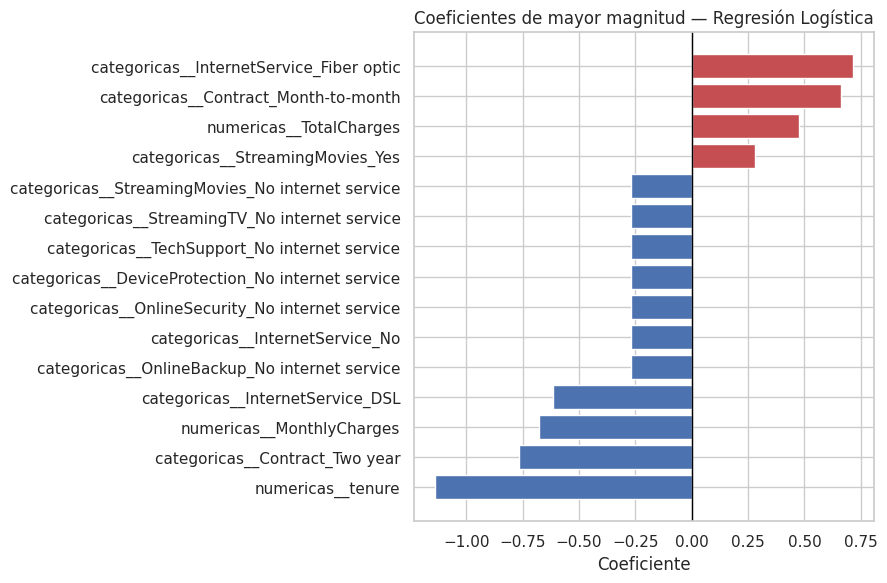

In [22]:
modelo_logistico = pipelines["Regresión Logística"]
nombres_variables = modelo_logistico.named_steps["preprocesamiento"].get_feature_names_out()
coeficientes = modelo_logistico.named_steps["modelo"].coef_[0]

tabla_coeficientes = (
    pd.DataFrame({"variable_transformada": nombres_variables, "coeficiente": coeficientes})
    .assign(magnitud=lambda x: x["coeficiente"].abs())
    .sort_values("magnitud", ascending=False)
)
display(tabla_coeficientes.head(20))

top = tabla_coeficientes.head(15).sort_values("coeficiente")
fig, ax = plt.subplots(figsize=(9, 6))
colores = np.where(top["coeficiente"] >= 0, "#C44E52", "#4C72B0")
ax.barh(top["variable_transformada"], top["coeficiente"], color=colores)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Coeficientes de mayor magnitud — Regresión Logística", xlabel="Coeficiente", ylabel="")
plt.tight_layout()
plt.show()

### Interpretación de los coeficientes

La variable `tenure` presenta el coeficiente de mayor magnitud y signo negativo, lo que indica que una mayor permanencia del cliente está asociada con una menor probabilidad estimada de abandono.

Los contratos de dos años también muestran una asociación negativa con el abandono, mientras que los contratos mes a mes presentan una asociación positiva.

Entre los servicios de internet, la categoría de fibra óptica aparece asociada con una mayor probabilidad estimada de abandono dentro del modelo.

Variables como `MonthlyCharges` y `TotalCharges` también presentan coeficientes de magnitud relevante, aunque su interpretación debe realizarse junto con el resto de variables incluidas en el modelo.

Estos resultados representan asociaciones aprendidas por la Regresión Logística y no deben interpretarse como relaciones causales.

## 15. Revisión de desempeño por grupos

Como parte del análisis de uso responsable del modelo, se realiza una revisión básica de su desempeño entre distintos grupos disponibles en el conjunto de datos.

Se comparan dos métricas:

- **Recall:** proporción de abandonos reales que el modelo logra detectar dentro de cada grupo.
- **Tasa de falsos positivos:** proporción de clientes que permanecieron, pero fueron clasificados incorrectamente como posibles abandonos.

La revisión se realiza para las variables `gender` y `SeniorCitizen`.

Este análisis no constituye por sí solo una evaluación completa de equidad algorítmica. Los grupos disponibles son limitados y las categorías del dataset son simplificadas. Una implementación real requeriría criterios legales, revisión periódica, participación de las personas afectadas y mecanismos de monitoreo continuo.

In [23]:
def metricas_por_grupo(variable, pred):
    auditoria_grupo = pd.DataFrame(
        {
            "grupo": X_test[variable],
            "real": y_test,
            "pred": pred,
        }
    )
    filas = []
    for grupo, datos in auditoria_grupo.groupby("grupo"):
        tn, fp, fn, tp = confusion_matrix(datos["real"], datos["pred"], labels=[0, 1]).ravel()
        filas.append(
            {
                "variable": variable,
                "grupo": grupo,
                "casos": len(datos),
                "tasa_real_abandono": datos["real"].mean(),
                "recall": tp / (tp + fn) if (tp + fn) else np.nan,
                "tasa_falsos_positivos": fp / (fp + tn) if (fp + tn) else np.nan,
            }
        )
    return pd.DataFrame(filas)

pred_final = predicciones["Regresión Logística"]
auditoria_etica = pd.concat(
    [metricas_por_grupo("gender", pred_final), metricas_por_grupo("SeniorCitizen", pred_final)],
    ignore_index=True,
)
display(auditoria_etica.round(3))

,variable,grupo,casos,tasa_real_abandono,recall,tasa_falsos_positivos
0,gender,Female,687,0.281,0.777,0.269
1,gender,Male,722,0.251,0.790,0.287
2,SeniorCitizen,No,1187,0.233,0.732,0.249
3,SeniorCitizen,Yes,222,0.441,0.929,0.492


### Interpretación de la revisión por grupos

El desempeño del modelo presenta valores relativamente similares entre hombres y mujeres. El `recall` fue de 0,777 para mujeres y 0,790 para hombres, mientras que la tasa de falsos positivos fue de 0,269 y 0,287, respectivamente.

Las diferencias son más marcadas según la condición de adulto mayor. En el grupo `SeniorCitizen = Yes`, el modelo alcanzó un `recall` de 0,929, frente a 0,732 en el grupo `SeniorCitizen = No`. Sin embargo, también presentó una tasa de falsos positivos considerablemente mayor: 0,492 frente a 0,249.

Estos resultados evidencian la importancia de revisar el comportamiento del modelo entre distintos grupos antes de una posible implementación. La presente revisión constituye una auditoría exploratoria y no permite concluir por sí sola que el modelo sea equitativo o discriminatorio.

## 16. Guardado de resultados

Una vez finalizado el entrenamiento, la evaluación y la auditoría del modelo, se guardan los principales resultados generados durante el proyecto.

Se almacenan:

- las métricas finales de comparación de los modelos;
- los resultados de la revisión de desempeño por grupos;
- el pipeline completo de Regresión Logística seleccionado como modelo principal.

Guardar el pipeline completo permite conservar tanto las transformaciones de preprocesamiento como el modelo entrenado, reduciendo errores al realizar predicciones futuras.

En Google Colab estos archivos se generan dentro del almacenamiento temporal de la sesión.

In [24]:
directorio_reportes = Path("reports")
directorio_modelos = Path("models")

# Crear carpetas si todavía no existen
directorio_reportes.mkdir(exist_ok=True)
directorio_modelos.mkdir(exist_ok=True)

# Guardar métricas finales de los modelos
tabla_test.to_csv(
    directorio_reportes / "metricas_modelos.csv"
)

# Guardar resultados de la auditoría por grupos
auditoria_etica.to_csv(
    directorio_reportes / "auditoria_grupos.csv",
    index=False
)

# Seleccionar el modelo principal
modelo_logistico = pipelines["Regresión Logística"]

# Guardar pipeline completo
joblib.dump(
    modelo_logistico,
    directorio_modelos / "modelo_churn_logistico.joblib"
)

print("Archivos generados:")
print("- reports/metricas_modelos.csv")
print("- reports/auditoria_grupos.csv")
print("- models/modelo_churn_logistico.joblib")

Archivos generados:
- reports/metricas_modelos.csv
- reports/auditoria_grupos.csv
- models/modelo_churn_logistico.joblib


## 17. Conclusiones y recomendaciones

### Conclusiones técnicas

1. El conjunto de datos analizado contiene 7.043 registros de clientes y permitió formular un problema de clasificación binaria, cuyo objetivo fue identificar clientes con posible riesgo de abandono (`Churn`).

2. Durante la preparación de los datos se identificó que la variable `TotalCharges` estaba almacenada como texto. Al convertirla a formato numérico se detectaron 11 valores faltantes correspondientes a clientes con `tenure = 0`. Estos casos fueron tratados asignando un valor de 0 a `TotalCharges`, conservando los 7.043 registros del conjunto de datos.

3. La variable objetivo presentó un desbalance moderado: el 73,46 % de los clientes no abandonó el servicio y el 26,54 % sí lo hizo. Por esta razón, el desempeño de los modelos no se evaluó únicamente mediante `accuracy`, sino también mediante `precision`, `recall`, `F1`, `ROC-AUC` y `PR-AUC`.

4. El análisis exploratorio permitió identificar asociaciones relevantes. Los clientes con contratos mes a mes presentaron una tasa de abandono del 42,71 %, frente al 11,27 % de los contratos de un año y al 2,83 % de los contratos de dos años. Asimismo, los clientes que abandonaron registraron una permanencia promedio de 17,98 meses, frente a 37,57 meses entre quienes permanecieron.

5. Se compararon tres alternativas: una línea base, Regresión Logística y Random Forest. La línea base obtuvo un `accuracy` de 0,735, pero un `recall` de 0, lo que demuestra que el `accuracy` por sí solo puede producir una interpretación engañosa cuando existe desbalance entre las clases.

6. En el conjunto de prueba, Random Forest obtuvo un `accuracy` de 0,774, `precision` de 0,560, `recall` de 0,682, `F1` de 0,615, `ROC-AUC` de 0,839 y `PR-AUC` de 0,645. Por su parte, la Regresión Logística obtuvo un `accuracy` de 0,738, `precision` de 0,504, `recall` de 0,783, `F1` de 0,614, `ROC-AUC` de 0,842 y `PR-AUC` de 0,633.

7.Para el objetivo planteado se seleccionó la Regresión Logística como modelo principal, priorizando su mayor `recall` y su facilidad de interpretación. El modelo identificó correctamente 293 de los 374 casos reales de abandono del conjunto de prueba, alcanzando un `recall` del 78,3 %.

Esta selección responde al objetivo de detectar una mayor proporción de clientes que realmente abandonan, aunque Random Forest obtuvo mejores resultados en otras métricas como `accuracy`, `precision`, `F1` y `PR-AUC`.

8. La interpretación de los coeficientes mostró asociaciones relevantes entre el abandono y variables como la permanencia (`tenure`), el tipo de contrato y el servicio de internet. Una mayor permanencia y los contratos de dos años se asociaron con menor probabilidad estimada de abandono, mientras que los contratos mes a mes se asociaron con una mayor probabilidad estimada. Estas asociaciones no deben interpretarse como relaciones causales.

### Recomendaciones empresariales

- Utilizar la probabilidad estimada de abandono como una señal de apoyo para identificar clientes que podrían requerir atención, evitando decisiones completamente automatizadas.
- Diseñar acciones voluntarias de retención, soporte o información para clientes identificados con mayor riesgo.
- Considerar variables como el tipo de contrato y la permanencia al diseñar estrategias de análisis y retención, debido a las asociaciones observadas con el abandono, sin asumir que estas características sean causas directas del comportamiento.
- Evaluar el costo empresarial de los falsos positivos frente al costo de no detectar a un cliente que finalmente abandona.
- Validar mediante experimentos controlados la efectividad de las acciones de retención antes de atribuirles efectos causales.
- Reentrenar y monitorear periódicamente el modelo cuando cambien los productos, precios, características de los clientes o patrones de comportamiento.

### Ética, privacidad y uso responsable

La auditoría por grupos mostró un comportamiento relativamente similar entre hombres y mujeres. El `recall` fue de 0,777 para mujeres y 0,790 para hombres, mientras que las tasas de falsos positivos fueron de 0,269 y 0,287, respectivamente.

Se observaron diferencias mayores según la condición de adulto mayor. El modelo alcanzó un `recall` de 0,929 en adultos mayores frente a 0,732 en los demás clientes. Sin embargo, la tasa de falsos positivos también fue considerablemente superior en adultos mayores: 0,492 frente a 0,249.

Estos resultados evidencian la necesidad de monitorear el desempeño del modelo entre distintos grupos antes de una eventual implementación. Esta revisión constituye una auditoría básica y no permite concluir por sí sola que el modelo sea equitativo o discriminatorio.

En una aplicación real también deberían implementarse medidas de protección de datos, control de acceso, minimización de información, documentación del modelo, supervisión humana y cumplimiento de la normativa de protección de datos aplicable.

### Limitaciones

- El conjunto de datos corresponde a un dataset público utilizado con fines de análisis y aprendizaje, por lo que los resultados no deben generalizarse directamente a una empresa real.
- El conjunto de datos no proporciona una estructura temporal longitudinal que permita analizar detalladamente la evolución de cada cliente a lo largo del tiempo.
- Las relaciones encontradas corresponden a asociaciones estadísticas y predictivas; no demuestran causalidad.
- El desempeño obtenido con este dataset no garantiza el mismo comportamiento en clientes de Ecuador o de otra empresa.
- La auditoría ética realizada es exploratoria y se limita a los grupos disponibles y analizados.
- Una implementación real requeriría validación con datos recientes y representativos de la organización.

### Próximos pasos

1. Validar el modelo utilizando datos recientes y representativos de una organización real.
2. Analizar el costo económico de falsos positivos y falsos negativos.
3. Evaluar diferentes umbrales de clasificación de acuerdo con los objetivos empresariales.
4. Monitorear posibles cambios en la distribución de los datos y en el desempeño del modelo.
5. Ampliar la evaluación de equidad y privacidad antes de una implementación.
6. Evaluar periódicamente si el modelo continúa siendo adecuado y requiere reentrenamiento.


## 18. Resumen del proyecto

En este proyecto se desarrolló un sistema de clasificación para identificar clientes con posible riesgo de abandono en una empresa de telecomunicaciones. Se utilizó un conjunto de datos de 7.043 clientes y 21 variables originales.

El proyecto incluyó las etapas de carga, auditoría, limpieza y preparación de datos, análisis exploratorio, visualización, consultas mediante SQL, preprocesamiento, entrenamiento, validación y evaluación de modelos de aprendizaje automático.

El análisis exploratorio mostró que el 26,54 % de los clientes abandonó el servicio y permitió identificar asociaciones entre el abandono y características como el tipo de contrato, la permanencia y los cargos del cliente.

Para el modelado se comparó una línea base con Regresión Logística y Random Forest. Los modelos fueron evaluados mediante validación cruzada y posteriormente sobre un conjunto de prueba independiente utilizando `accuracy`, `precision`, `recall`, `F1`, `ROC-AUC` y `PR-AUC`.

La Regresión Logística fue seleccionada como modelo principal debido principalmente a su mayor `recall` y a su facilidad de interpretación para el objetivo planteado. En el conjunto de prueba obtuvo un `recall` de 0,783 y un `ROC-AUC` de 0,842, identificando correctamente 293 de los 374 casos reales de abandono.

Finalmente, se realizó una auditoría básica del desempeño por grupos, se analizaron aspectos de privacidad, sesgo y uso responsable de los datos, y se guardaron las métricas, los resultados de auditoría y el modelo entrenado para favorecer la reproducibilidad del proyecto.